# Visualize results - a walktrough 

This notebook includes a walktrough, to help visulaize results. Helper functions to make visualization are found in src/visuals.py

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from utils.visuals import *

Specify which results to viasualize, by filling out the name and data of the experiments. THis only works if resluts are saved as *./results/YYYY-DD-MM/'name of experiment'*.

In [25]:
EXPERIMENT = 'nih_age'
DATE = '2026-09-02'          # set to None to auto-use the latest available date
load_results(date_overrides={EXPERIMENT: DATE}, experiments=[EXPERIMENT])


{'nih_age': PosixPath('/Users/sarasterlie/uncertainty-benchmark/results/2026-09-02/nih_age')}

## Sample distribution per OOD level 
Run cell below to get the sample distribution for each fine-grained OOD level as bar-plot.

Saved → /Users/sarasterlie/uncertainty-benchmark/plots/distribution_nih_age.pdf


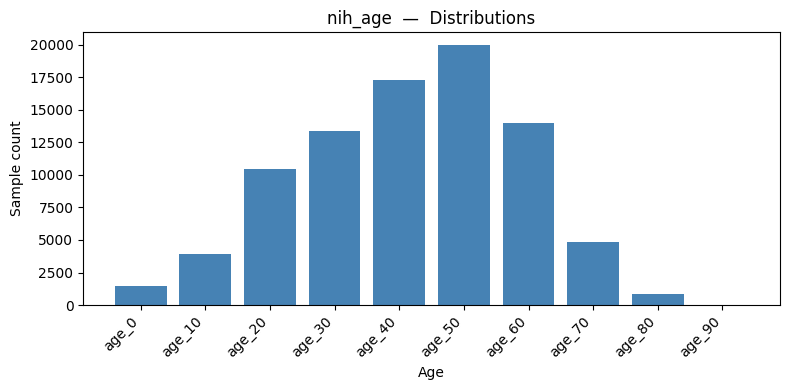

In [26]:
plot_distribution(EXPERIMENT)

## Fine grained OOD over distortion pattern 
Run the cell below to get uncertainty (aleatoric, epistemic and total) for each method over the experiment specific distortion pattern, plotted by one window pr. method. Similar to figure 3 of inthe paper. 

Saved → /Users/sarasterlie/uncertainty-benchmark/plots/method_grid_nih_age.pdf


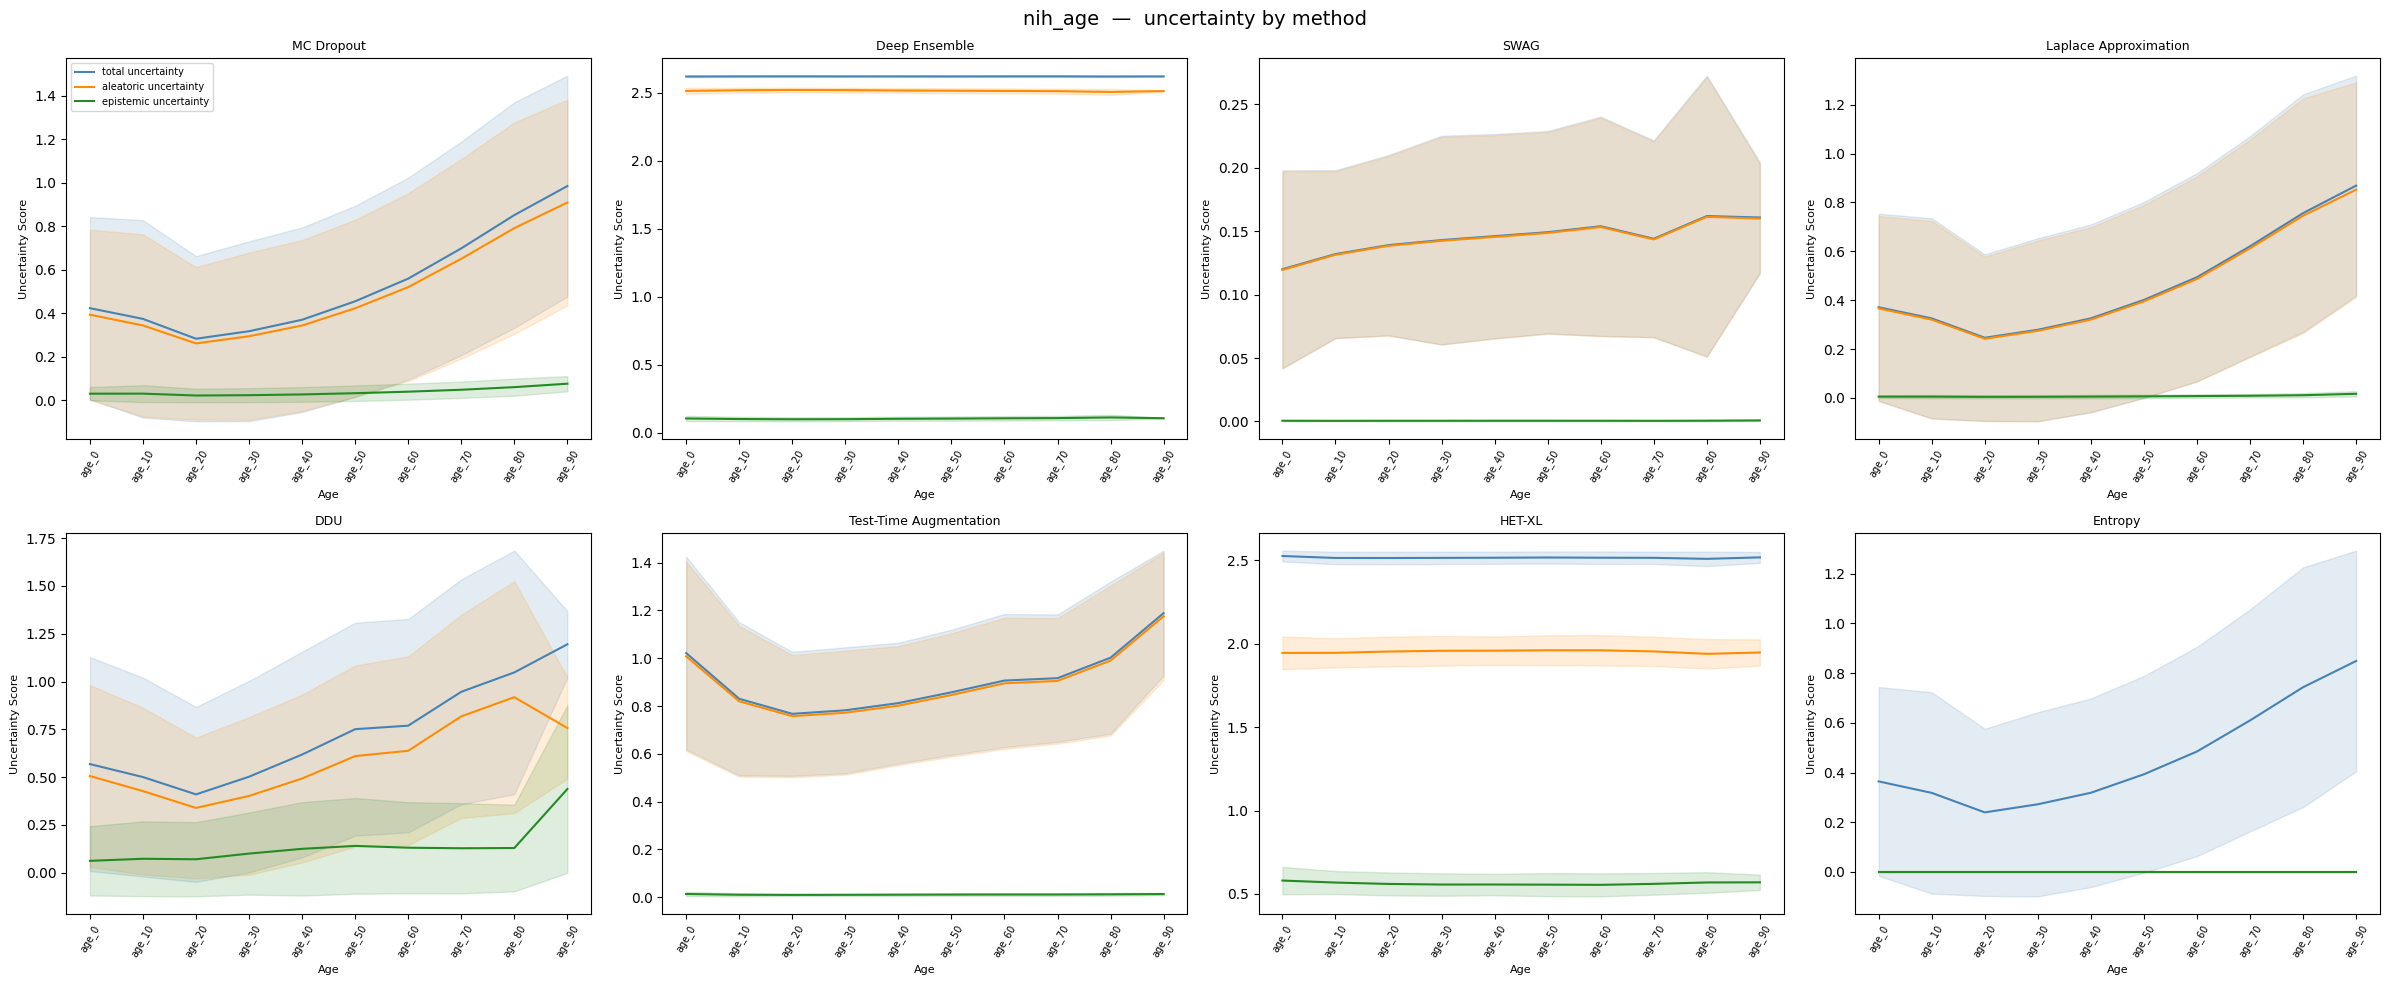

In [27]:
# Per-method grid: each method gets its own panel, all 3 uncertainty types overlaid
plot_method_grid(EXPERIMENT)

## OOD AUROC of epistemic tasks 
Run the below cell to get the OOD detection AUROC (only relevant for epistemic tasks). Similar to figure 5 in the paper. 

Saved → /Users/sarasterlie/uncertainty-benchmark/plots/ood_auroc_nih_age_total_uncertainty.pdf


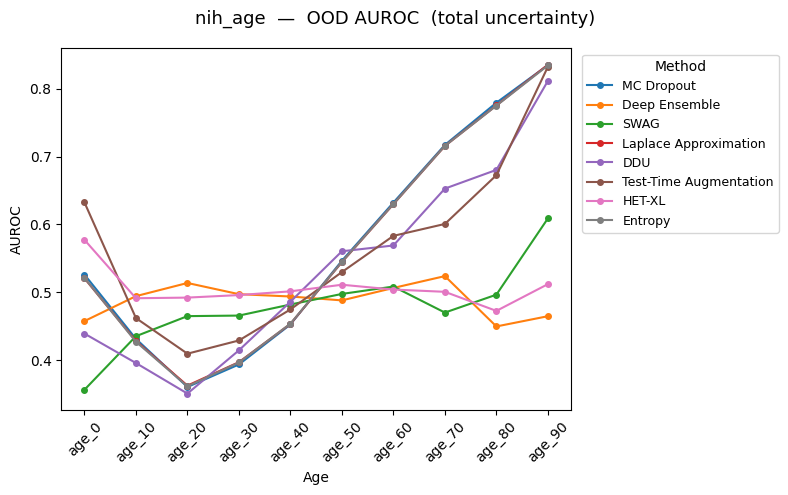

In [28]:
# OOD AUROC: 1×3 — epistemic / aleatoric / total side by side
plot_ood_auroc(EXPERIMENT)

# Misclassification task Bar-plot

The following cells plots the resutls of the aleatoric task for chest x-ray images. Initialize by fetching the relevant results, by running the cell below. 

In [ ]:
# One call with both experiments — load_results() clears previous results each time it's called,
# so loading them separately would wipe out the first one.
load_results(
    date_overrides={EXPERIMENT_vin: DATE, EXPERIMENT_chex: DATE},
    experiments=[EXPERIMENT_vin, EXPERIMENT_chex],
)

{'vin_amb': PosixPath('/Users/sarasterlie/uncertainty-benchmark/results/2026-09-01/vin_amb'),
 'chexpert_amb': PosixPath('/Users/sarasterlie/uncertainty-benchmark/results/2026-09-01/chexpert_amb')}

Run the cell below to plot the ambiguity-detection AUROC: how well the aleatoric uncertainty score detects subjects with uncertain labels (CheXpert) or multi-rater disagreement (VinDr-CXR). Similar to figure 4a in the paper.

Saved → /Users/sarasterlie/uncertainty-benchmark/plots/ambiguity_auroc_compare_vin_amb_vs_chexpert_amb.pdf


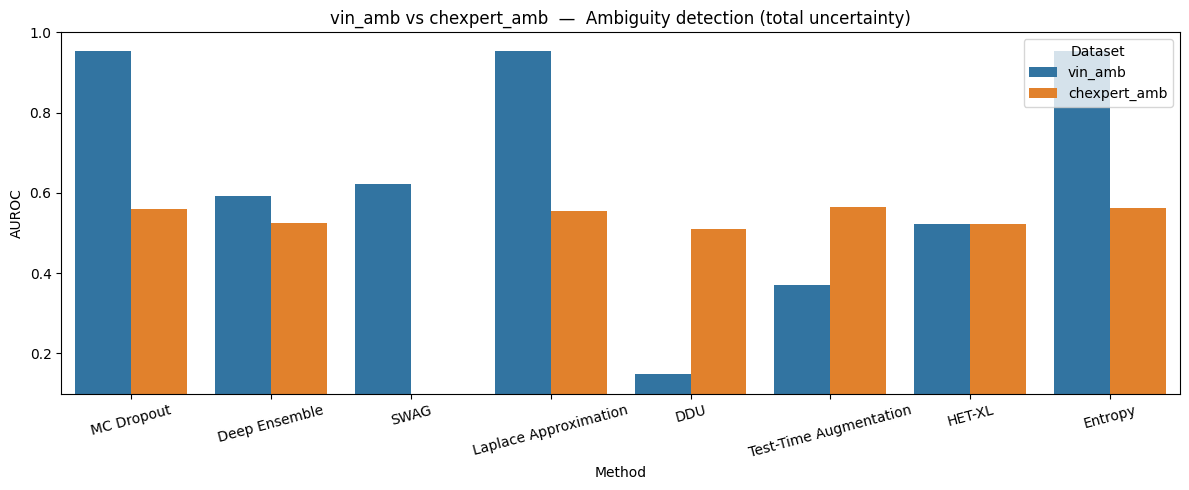

In [35]:
plot_ambiguity_auroc_compare(EXPERIMENT_vin, EXPERIMENT_chex)

Run the cell below to plot the misclassification-detection AUROC: the performance of total predictive uncertainty in detecting misclassifications of the underlying model. Similar to figure 4b in the paper.

Saved → /Users/sarasterlie/uncertainty-benchmark/plots/misclassification_auroc_compare_vin_amb_vs_chexpert_amb.pdf


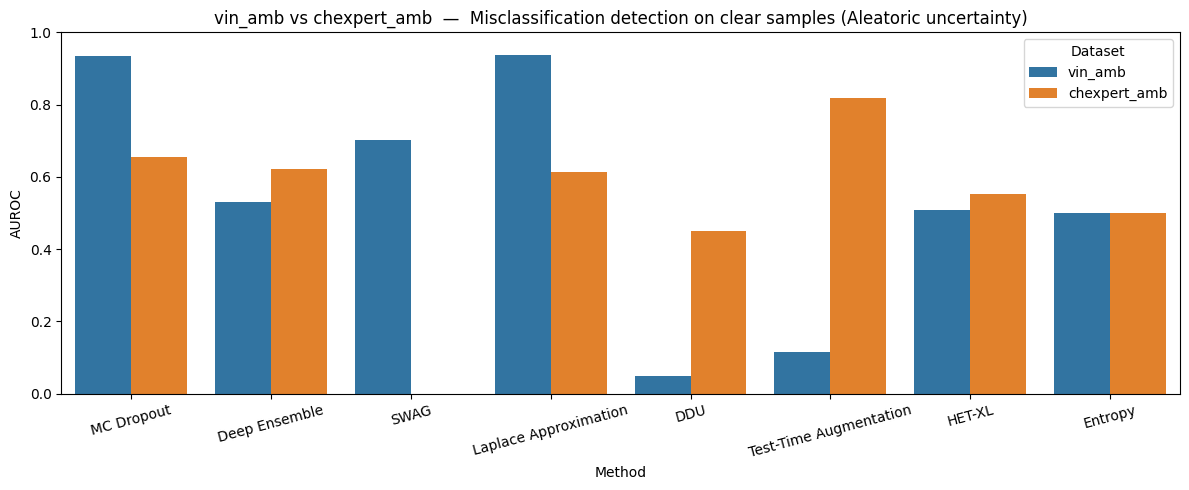

In [34]:
plot_misclassification_auroc_compare(EXPERIMENT_vin, EXPERIMENT_chex)